# Äquivalenzvergleich: Zeitexpandierter MILP-Solver vs. A*-Router

## Hintergrund

**Einzelne Sendung:** Da für eine einzelne Sendung das Problem der optimalen Routenwahl ein klassisches Kürzeste-Weg-Problem auf dem zeitexpandierten Graphen darstellt, müssen sowohl der MILP-Solver als auch der A*-Router exakt dasselbe Ergebnis liefern.

---

## 1. Setup und Imports

In [1]:
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from freight_routing.data_loader import NetworkDataLoader
from freight_routing.data_models import Shipment, ObjectiveWeights
from freight_routing.model import TimeExpandedFreightRoutingModel, TimeExpandedNetwork
from heuristics.dijkstra_router import AStarRouter

## 2. Laden des Netzwerks

In [2]:
network_path = PROJECT_ROOT / "dataset/large_network.json"
print(f"Loading network from {network_path}...")
network_data = NetworkDataLoader.from_json(network_path)
network_data.summary()

Loading network from /home/benedikt/Projects/Sustainable_Freight_Mode_Choice/dataset/large_network.json...


Summary NetworkData:
hubs=870
arcs=36272
modes=4


## 3. Definition einer einzelnen Sendung für den ersten Test

In [3]:
shipment_1 = Shipment(
    id="user_shipment_1",
    start_hub="ALG_185",
    end_hub="ORA_186",
    start_time=0,
    deadline=2880,  # 2 Tage Horizont
    max_price=1_000_000.0,
    max_emissions=None,
    weight=2.0,
)

## 4. Basis-Äquivalenztest (Kostenminimierung)

In [4]:
weights_cost = ObjectiveWeights(cost=1.0, emissions=0.0, time=0.0)

# MILP
network_1 = TimeExpandedNetwork.build(
    network_data, planning_days=2, shipments=[shipment_1]
)
milp_model = TimeExpandedFreightRoutingModel(objective_weights=weights_cost)
milp_res = milp_model.solve(network_1)

# A*
astar_router = AStarRouter(objective_weights=weights_cost)
astar_res = astar_router.solve(network_1)

print("--- Basis-Kostenoptimierung ---")
print(
    f"MILP Cost: {milp_res.total_cost:.2f} EUR | A* Cost: {astar_res.total_cost:.2f} EUR"
)
milp_route = milp_res.shipment_routes[shipment_1.id]
astar_route = astar_res.shipment_routes[shipment_1.id]
milp_path = " -> ".join(f"{arc.from_node.hub_id}({arc.mode})" for arc in milp_route)
astar_path = " -> ".join(f"{arc.from_node.hub_id}({arc.mode})" for arc in astar_route)
print(f"Pfade identisch: {milp_path == astar_path}")

--- Basis-Kostenoptimierung ---
MILP Cost: 1260.80 EUR | A* Cost: 1260.80 EUR
Pfade identisch: True


## 5. Äquivalenztest mit unterschiedlichen Zielfunktions-Gewichten

1. **Reine Kostenoptimierung**
2. **Reine Emissionsoptimierung**
3. **Reine Zeitoptimierung**
4. **Ausgewogene Optimierung**

**Hinweis zu Einzelszenarien:** Bei reinen Einzelszenarien (z. B. nur Emissions- oder Zeitoptimierung) kann es theoretisch mehrere mathematisch gleichwertige Pfade geben. Da z.B. das Warten an Hubs 0 CO2-Emissionen verursachen kann, ist jeder Abfahrtszeitpunkt für die Emissionen gleichermaßen optimal. A* wählt den frühesten Start, während der MILP-Solver einen beliebigen gleichwertigen Pfad wählt.

In [5]:
scenarios = [
    ("Reine Kostenoptimierung", ObjectiveWeights(cost=1.0, emissions=0.0, time=0.0)),
    ("Reine Emissionsoptimierung", ObjectiveWeights(cost=0.0, emissions=1.0, time=0.0)),
    ("Reine Zeitoptimierung", ObjectiveWeights(cost=0.0, emissions=0.0, time=1.0)),
    ("Ausgewogene Optimierung", ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)),
]

for name, scenario_weights in scenarios:
    print(f"\n=== Szenario: {name} ===")

    # MILP
    net = TimeExpandedNetwork.build(
        network_data, planning_days=2, shipments=[shipment_1]
    )
    m_model = TimeExpandedFreightRoutingModel(objective_weights=scenario_weights)
    m_res = m_model.solve(net)

    # A*
    astar_router = AStarRouter(objective_weights=scenario_weights)
    astar_res = astar_router.solve(net)

    if m_res.is_optimal and astar_res.is_optimal:
        m_route = m_res.shipment_routes[shipment_1.id]
        astar_route = astar_res.shipment_routes[shipment_1.id]
        m_path = " -> ".join(f"{arc.from_node.hub_id}({arc.mode})" for arc in m_route)
        astar_path = " -> ".join(
            f"{arc.from_node.hub_id}({arc.mode})" for arc in astar_route
        )

        cost_diff = abs(m_res.total_cost - astar_res.total_cost)
        time_diff = abs(m_res.total_time - astar_res.total_time)
        emissions_diff = abs(m_res.total_emissions - astar_res.total_emissions)
        obj_diff = (
            abs(m_res.objective_value - astar_res.objective_value)
            if (
                m_res.objective_value is not None
                and astar_res.objective_value is not None
            )
            else 0.0
        )

        print(
            f"  Kosten: MILP={m_res.total_cost:.2f} EUR | A*={astar_res.total_cost:.2f} EUR"
        )
        print(
            f"  CO2:    MILP={m_res.total_emissions:.2f} kg  | A*={astar_res.total_emissions:.2f} kg"
        )
        print(
            f"  Dauer:  MILP={m_res.total_time:.2f} min | A*={astar_res.total_time:.2f} min"
        )
        print(f"  Pfade identisch: {m_path == astar_path}")

        if "Kosten" in name:
            assert cost_diff < 1e-3, f"Kosten weichen ab: {cost_diff}"
        elif "Emission" in name:
            assert emissions_diff < 1e-3, f"Emissionen weichen ab: {emissions_diff}"
        elif "Zeit" in name:
            assert time_diff < 1e-3, f"Dauer weicht ab: {time_diff}"
        else:
            assert obj_diff < 1e-3, f"Zielfunktionswert weicht ab: {obj_diff}"

        print(f"  [ERFOLG] Äquivalenz verifiziert!")
    else:
        print("  [FEHLER] Einer der Algorithmen fand keine Lösung.")


=== Szenario: Reine Kostenoptimierung ===


  Kosten: MILP=1260.80 EUR | A*=1260.80 EUR
  CO2:    MILP=134.28 kg  | A*=134.28 kg
  Dauer:  MILP=2498.00 min | A*=2498.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!

=== Szenario: Reine Emissionsoptimierung ===


  Kosten: MILP=1260.80 EUR | A*=1260.80 EUR
  CO2:    MILP=134.28 kg  | A*=134.28 kg
  Dauer:  MILP=2498.00 min | A*=2498.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!

=== Szenario: Reine Zeitoptimierung ===


  Kosten: MILP=1727.49 EUR | A*=1727.49 EUR
  CO2:    MILP=202.96 kg  | A*=202.96 kg
  Dauer:  MILP=484.00 min | A*=484.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!

=== Szenario: Ausgewogene Optimierung ===


  Kosten: MILP=1727.49 EUR | A*=1727.49 EUR
  CO2:    MILP=202.96 kg  | A*=202.96 kg
  Dauer:  MILP=484.00 min | A*=484.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!


## 6. Vergleich für mehrere Sendungen mit Konsolidierung

In [6]:
# Definition der Sendungen
from freight_routing.data_models import Shipment, ObjectiveWeights, ArcType

shipment_m1 = Shipment(
    id="shipment_m1",
    start_hub="ALG_185",
    end_hub="ANT_1109",
    start_time=0,
    deadline=2880,
    max_price=1000000.0,
    max_emissions=None,
    weight=15.0,
)
shipment_m2 = Shipment(
    id="shipment_m2",
    start_hub="ALG_185",
    end_hub="GEN_1110",
    start_time=0,
    deadline=2880,
    max_price=1000000.0,
    max_emissions=None,
    weight=25.0,
)
multi_shipments = [shipment_m1, shipment_m2]
weights_multi = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)


def format_route(route) -> str:
    segments = []
    for arc in route:
        if arc.arc_type == ArcType.TRANSPORT:
            segments.append(
                f"{arc.from_node.hub_id} -> {arc.to_node.hub_id} ({arc.mode})"
            )
        elif arc.arc_type == ArcType.WAITING:
            segments.append(
                f"Wait@{arc.from_node.hub_id}({arc.mode}, {arc.duration_min}min)"
            )
        elif arc.arc_type == ArcType.TRANSFER:
            segments.append(
                f"Transfer@{arc.from_node.hub_id}({arc.from_node.mode} -> {arc.to_node.mode})"
            )
    return " | ".join(segments)


print("=== 1. MILP-Solver für mehrere Sendungen ===")
net_multi = TimeExpandedNetwork.build(
    network_data, planning_days=2, shipments=multi_shipments
)
milp_multi_model = TimeExpandedFreightRoutingModel(objective_weights=weights_multi)
res_milp_multi = milp_multi_model.solve(net_multi)

print(f"Status: {res_milp_multi.status}")
print(f"Kosten: {res_milp_multi.total_cost:.2f} EUR")
print(f"CO2:    {res_milp_multi.total_emissions:.2f} kg")
print(f"Kombinierter Zielfunktionswert: {res_milp_multi.objective_value:.6f}")
print(f"Konsolidiert: {res_milp_multi.is_consolidated}")
print("Routen:")
for s_id, route in res_milp_multi.shipment_routes.items():
    print(f"  {s_id}: {format_route(route)}")

print("\n=== 2. Heuristik-Router (solve_multiple + LNS optimize_multiple) ===")
astar_multi_router = AStarRouter(objective_weights=weights_multi)
res_heur_multi = astar_multi_router.solve_multiple(net_multi)
res_opt_multi = astar_multi_router.optimize_multiple(
    res_heur_multi,
    network=net_multi,
    iterations=20,
    ruin_fraction=0.5,
    seed=42,
)

print(f"Status (Greedy): {res_heur_multi.status}")
print(f"Kosten (Greedy): {res_heur_multi.total_cost:.2f} EUR")
print(f"Status (Optimiert): {res_opt_multi.status}")
print(f"Kosten (Optimiert): {res_opt_multi.total_cost:.2f} EUR")
print(f"CO2 (Optimiert):    {res_opt_multi.total_emissions:.2f} kg")
print(
    f"Kombinierter Zielfunktionswert (Optimiert): {res_opt_multi.objective_value:.6f}"
)
print(f"Konsolidiert: {res_opt_multi.is_consolidated}")
print("Routen (Optimiert):")
for s_id, route in res_opt_multi.shipment_routes.items():
    print(f"  {s_id}: {format_route(route)}")

# Verifikation
assert (
    abs(res_milp_multi.total_cost - res_opt_multi.total_cost) < 1e-3
), "Kosten weichen ab!"
assert (
    abs(res_milp_multi.total_emissions - res_opt_multi.total_emissions) < 1e-3
), "Emissionen weichen ab!"
assert res_opt_multi.is_consolidated is True, "Konsolidierung wurde nicht erkannt!"
print("\n[ERFOLG] Bündelung und mathematische Äquivalenz verifiziert!")

=== 1. MILP-Solver für mehrere Sendungen ===


Status: Optimal
Kosten: 230252.33 EUR
CO2:    38087.97 kg
Kombinierter Zielfunktionswert: 0.236387
Konsolidiert: True
Routen:
  shipment_m1: Wait@ALG_185(air, 300min) | Wait@ALG_185(air, 180min) | Wait@ALG_185(air, 60min) | ALG_185 -> PAR_3672 (air) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 11min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 6min) | Wait@PAR_3672(air, 5min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 10min) | Wait@PAR_3672(air, 14min) | Wait@PAR_3672(air, 10min) | Wait@PAR_3672(air, 28min) | Wait@PAR_3672(air, 23min) | Wait@PAR_3672(air, 40min) | Wait@PAR_3672(air, 17min) | Wait@PAR_3672(air, 3min) | Wait@PAR_36

Status (Greedy): Feasible
Kosten (Greedy): 230252.33 EUR
Status (Optimiert): Feasible
Kosten (Optimiert): 230252.33 EUR
CO2 (Optimiert):    38087.98 kg
Kombinierter Zielfunktionswert (Optimiert): 0.236387
Konsolidiert: True
Routen (Optimiert):
  shipment_m2: Wait@ALG_185(air, 300min) | Wait@ALG_185(air, 180min) | Wait@ALG_185(air, 60min) | ALG_185 -> PAR_3672 (air) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 11min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 6min) | Wait@PAR_3672(air, 5min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 10min) | Wait@PAR_3672(air, 14min) | Wait@PAR_3672(air, 10min) | Wait@PAR_3672(air, 28min) | Wait

## 7. Vergleich auf hoher Konsolidierungsdichte

In [7]:
# Laden des mittleren Netzwerks
medium_network_data = NetworkDataLoader.from_json("../dataset/medium_network.json")

import random
import time

# Generierung von 20 zufälligen Sendungen
random.seed(42)
N_SHIPMENTS = 50

hubs_list = list(medium_network_data.hubs.keys())
test_shipments = []
for i in range(N_SHIPMENTS):
    start = random.choice(hubs_list)
    dest = random.choice(hubs_list)
    while dest == start:
        dest = random.choice(hubs_list)

    test_shipments.append(
        Shipment(
            id=f"shipment_{i}",
            start_hub=start,
            end_hub=dest,
            start_time=0,
            deadline=2880,
            max_price=1000000.0,
            max_emissions=None,
            weight=float(random.randint(1, 10)),
        )
    )

weights_medium = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)

print(f"{N_SHIPMENTS} Sendungen generiert.")

print("=== 1. MILP-Solver ===")
t0 = time.time()
net_medium = TimeExpandedNetwork.build(
    medium_network_data, planning_days=2, shipments=test_shipments
)
milp_medium = TimeExpandedFreightRoutingModel(objective_weights=weights_medium)
net_medium.summary()
res_milp_medium = milp_medium.solve(net_medium)
t_milp = time.time() - t0

print(f"Status: {res_milp_medium.status}")
print(f"Kosten: {res_milp_medium.total_cost:.2f} EUR")
print(f"CO2:    {res_milp_medium.total_emissions:.2f} kg")
print(f"Kombinierter Zielfunktionswert: {res_milp_medium.objective_value:.6f}")
print(f"Konsolidiert: {res_milp_medium.is_consolidated}")
print(f"Rechenzeit MILP: {t_milp:.2f} s")

print("\n=== 2. Heuristik-Router (solve_multiple + LNS optimize_multiple) ===")
t0 = time.time()
astar_medium_router = AStarRouter(objective_weights=weights_medium)

res_heur_medium = astar_medium_router.solve_multiple(net_medium)
res_opt_medium = astar_medium_router.optimize_multiple(
    res_heur_medium,
    network=net_medium,
    iterations=50,
    ruin_fraction=0.2,
    seed=42,
)
t_heur = time.time() - t0

print(f"Status (Greedy): {res_heur_medium.status}")
print(f"Kosten (Greedy): {res_heur_medium.total_cost:.2f} EUR")
print(f"Status (Optimiert): {res_opt_medium.status}")
print(f"Kosten (Optimiert): {res_opt_medium.total_cost:.2f} EUR")
print(f"CO2 (Optimiert):    {res_opt_medium.total_emissions:.2f} kg")
print(
    f"Kombinierter Zielfunktionswert (Optimiert): {res_opt_medium.objective_value:.6f}"
)
print(f"Konsolidiert: {res_opt_medium.is_consolidated}")
print(f"Rechenzeit Heuristik (gesamt): {t_heur:.2f} s")
if not res_opt_medium.is_optimal:
    print("Diagnostics:")
    for d in res_opt_medium.diagnostics:
        print(d)

# Verifikation
assert res_opt_medium.is_consolidated is True, "Konsolidierung wurde nicht erkannt!"

50 Sendungen generiert.
=== 1. MILP-Solver ===
Summary TimeExpandedNetwork:
planning_days=2
planning_horizon_min=2880
shipments=50
nodes=14941
arcs=25322
  - transport_arcs=7988
  - transfer_arcs=2656
  - waiting_arcs=14678


Status: Infeasible
Kosten: 0.00 EUR
CO2:    0.00 kg
Kombinierter Zielfunktionswert: -3.088958
Konsolidiert: False
Rechenzeit MILP: 129.34 s

=== 2. Heuristik-Router (solve_multiple + LNS optimize_multiple) ===


Status (Greedy): Feasible
Kosten (Greedy): 4721205.59 EUR
Status (Optimiert): Feasible
Kosten (Optimiert): 4721205.59 EUR
CO2 (Optimiert):    806358.47 kg
Kombinierter Zielfunktionswert (Optimiert): 6.174972
Konsolidiert: True
Rechenzeit Heuristik (gesamt): 1.71 s
Diagnostics:
Shipment shipment_3: No feasible path found.
Shipment shipment_6: No feasible path found.
Shipment shipment_7: No feasible path found.
Shipment shipment_31: No feasible path found.
Shipment shipment_40: No feasible path found.
Shipment shipment_9: No feasible path found.
Shipment shipment_37: No feasible path found.
Shipment shipment_48: No feasible path found.
Shipment shipment_13: No feasible path found.
Shipment shipment_34: No feasible path found.
Shipment shipment_36: No feasible path found.
Shipment shipment_22: No feasible path found.
Shipment shipment_1: No feasible path found.
Shipment shipment_20: No feasible path found.
Shipment shipment_43: No feasible path found.
Shipment shipment_2: No feasible path

## 8. Skalierungs- und Genauigkeitsvergleich

1. **Die Genauigkeit**: Wie nah die Heuristik (vor/nach LNS) an das globale Optimum herankommt.
2. **Die Rechenzeit**: Wie sich die Rechenzeiten bei steigender Anzahl von Sendungen entwickeln.


Resuming from existing results in ./results/astar_vs_solver_accuracy.json. Already computed sizes: [1, 2, 4, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]


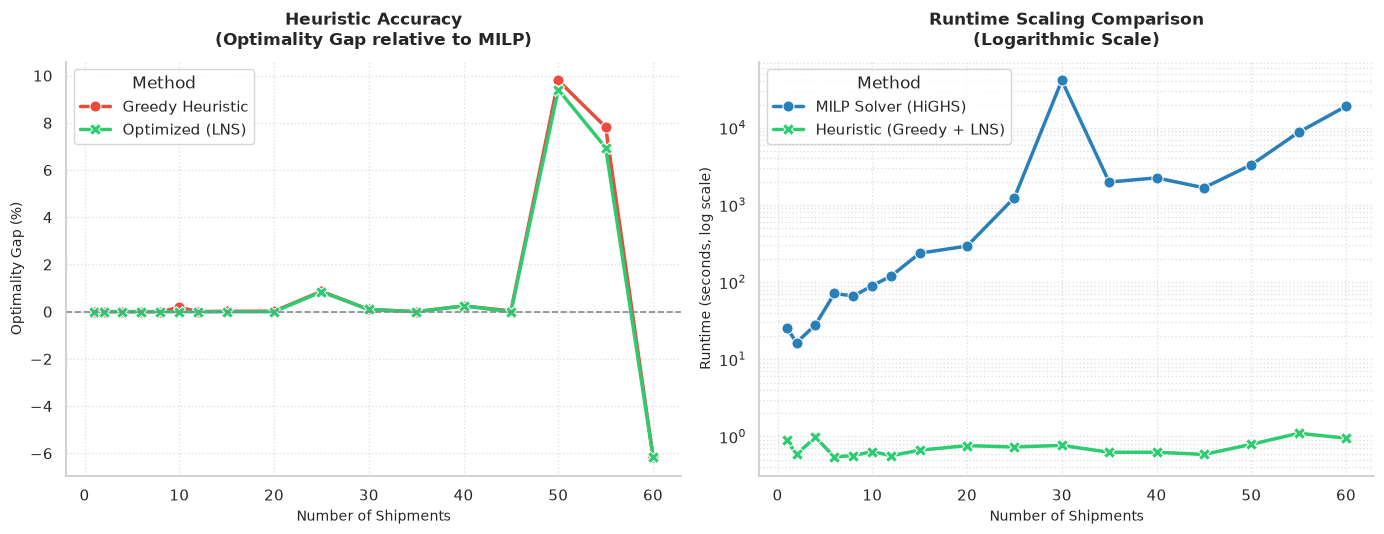

In [8]:
# Systematischer Benchmark und Plotting
import json
import os
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Parameter
shipment_sizes = [1, 2, 4, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
results_file = "./results/astar_vs_solver_accuracy.json"

# Check for existing results to resume from
if os.path.exists(results_file):
    with open(results_file, "r") as f:
        results = json.load(f)
    print(
        f"Resuming from existing results in {results_file}. Already computed sizes: {results['size']}"
    )
else:
    results = {
        "size": [],
        "milp_obj": [],
        "milp_time": [],
        "greedy_obj": [],
        "greedy_time": [],
        "opt_obj": [],
        "opt_time": [],
    }

completed_sizes = set(results["size"])

# Medium Netzwerk laden (Relativer Pfad aus dem notebooks-Ordner)
medium_network_data = NetworkDataLoader.from_json("../dataset/small_network.json")
weights_medium = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)
hubs_list = list(medium_network_data.hubs.keys())

for size in shipment_sizes:
    if size in completed_sizes:
        continue

    random.seed(43 + size)

    # Generiere zufällige Sendungen
    shipments = []
    for i in range(size):
        start = random.choice(hubs_list)
        dest = random.choice(hubs_list)
        while dest == start:
            dest = random.choice(hubs_list)
        shipments.append(
            Shipment(
                id=f"bench_s_{i}",
                start_hub=start,
                end_hub=dest,
                start_time=0,
                deadline=2880,
                max_price=1000000.0,
                max_emissions=None,
                weight=float(random.randint(1, 10)),
            )
        )

    # Zeitunabhängiger Graphenaufbau
    shared_network = TimeExpandedNetwork.build(
        medium_network_data, planning_days=15, shipments=shipments
    )
    shared_model = TimeExpandedFreightRoutingModel(objective_weights=weights_medium)

    # 1. Löse MILP (reine Lösungszeit)
    t0 = time.time()
    res_milp = shared_model.solve(network=shared_network, show_progress=True)
    t_milp = time.time() - t0

    # Falls die Instanz für das MILP unzulässig ist, brechen wir den Vergleich ab
    if res_milp.status != "Optimal":
        print(
            f"Abbruch bei {size} Sendungen: MILP nicht optimal (Status: {res_milp.status})"
        )
        break

    # 2. Löse Heuristik mit dem vorbereiteten Netzwerk (reine Lösungszeit)
    router = AStarRouter(weights_medium)

    # Greedy (solve_multiple mit übergebenem Netzwerk)
    t0 = time.time()
    res_greedy = router.solve_multiple(network=shared_network)
    t_greedy = time.time() - t0

    # LNS Optimierung (optimize_multiple mit übergebenem Netzwerk)
    t0 = time.time()
    res_opt = router.optimize_multiple(
        res_greedy, network=shared_network, iterations=40, ruin_fraction=0.15, seed=42
    )
    t_opt = time.time() - t0

    # Ergebnisse aufzeichnen
    results["size"].append(size)
    results["milp_obj"].append(res_milp.objective_value)
    results["milp_time"].append(t_milp)
    results["greedy_obj"].append(res_greedy.objective_value)
    results["greedy_time"].append(t_greedy)
    results["opt_obj"].append(res_opt.objective_value)
    results["opt_time"].append(t_greedy + t_opt)

    # Zwischenstand speichern
    with open(results_file, "w") as f:
        json.dump(results, f, indent=4)

    print(f"[Erfolg] {size} Sendung(en) getestet.")

# Plotten der Ergebnisse
sizes = results["size"]
if sizes:
    # Convert data to long-form DataFrames for Seaborn plotting
    greedy_gaps = [
        (g - m) / m * 100 for g, m in zip(results["greedy_obj"], results["milp_obj"])
    ]
    opt_gaps = [
        (o - m) / m * 100 for o, m in zip(results["opt_obj"], results["milp_obj"])
    ]

    df_gap = pd.DataFrame(
        {
            "Shipment Size": sizes * 2,
            "Optimality Gap (%)": greedy_gaps + opt_gaps,
            "Method": ["Greedy Heuristic"] * len(sizes)
            + ["Optimized (LNS)"] * len(sizes),
        }
    )

    df_time = pd.DataFrame(
        {
            "Shipment Size": sizes * 2,
            "Runtime (seconds)": results["milp_time"] + results["opt_time"],
            "Method": ["MILP Solver (HiGHS)"] * len(sizes)
            + ["Heuristic (Greedy + LNS)"] * len(sizes),
        }
    )

    sns.set_theme(style="whitegrid", palette="muted")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Plot 1: Optimality Gap
    sns.lineplot(
        data=df_gap,
        x="Shipment Size",
        y="Optimality Gap (%)",
        hue="Method",
        style="Method",
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=8,
        ax=ax1,
        palette={"Greedy Heuristic": "#e74c3c", "Optimized (LNS)": "#2ecc71"},
    )
    ax1.axhline(0, color="#7f8c8d", linestyle="--", linewidth=1.2)
    ax1.set_title(
        "Heuristic Accuracy\n(Optimality Gap relative to MILP)",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax1.set_xlabel("Number of Shipments", fontsize=10)
    ax1.set_ylabel("Optimality Gap (%)", fontsize=10)
    ax1.grid(True, linestyle=":", alpha=0.6)

    # Plot 2: Rechenzeiten
    sns.lineplot(
        data=df_time,
        x="Shipment Size",
        y="Runtime (seconds)",
        hue="Method",
        style="Method",
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=8,
        ax=ax2,
        palette={
            "MILP Solver (HiGHS)": "#2980b9",
            "Heuristic (Greedy + LNS)": "#2ecc71",
        },
    )
    ax2.set_yscale("log")
    ax2.set_title(
        "Runtime Scaling Comparison\n(Logarithmic Scale)",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax2.set_xlabel("Number of Shipments", fontsize=10)
    ax2.set_ylabel("Runtime (seconds, log scale)", fontsize=10)
    ax2.grid(True, which="both", linestyle=":", alpha=0.6)

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")

# 9. Neuer, geschachtelter Genauigkeits- und Skalierungsvergleich (Nested Design)

Um die Instanzvarianz der zufälligen Sendungsgenerierung zu eliminieren (die dazu führt, dass die Kurven der Rechenzeiten und Genauigkeiten schwanken oder bei Congestion unlösbar/unvergleichbar werden), implementieren wir hier einen geschachtelten Benchmark.

- **Geschachtelter Shipment-Pool**: Wir generieren einen festen Pool von 100 Sendungen. Jede Benchmark-Größe verwendet ein echtes Subset dieses Pools (`shipments[:size]`).
- **Kürzerer Planungshorizont (`planning_days=3`)**: Dies verringert die Graphgröße erheblich, beschleunigt den MILP-Solver massiv und erlaubt es, höhere Bündelungs- und Auslastungsraten in Sekunden statt in Stunden zu testen.
- **Strikte Lösbarkeitsprüfung**: Der Benchmark bricht ab, sobald die Heuristik nicht mehr alle Sendungen routen kann (denn ansonsten verfälschen ungeroutete Sendungen den Zielfunktionswert nach unten).

In [9]:
# Systematischer geschachtelter Benchmark und Plotting
import json
import os
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from freight_routing.data_loader import NetworkDataLoader
from freight_routing.data_models import Shipment, ObjectiveWeights
from freight_routing.model import TimeExpandedNetwork, TimeExpandedFreightRoutingModel
from heuristics.dijkstra_router import AStarRouter

# Parameter
shipment_sizes = [1, 2, 4, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 80, 90, 100]
results_file_nested = "./results/astar_vs_solver_accuracy_nested.json"

# Check for existing results to resume from
if os.path.exists(results_file_nested):
    with open(results_file_nested, "r") as f:
        results_nested = json.load(f)
    print(
        f"Resuming from existing nested results in {results_file_nested}. Already computed sizes: {results_nested['size']}"
    )
else:
    results_nested = {
        "size": [],
        "milp_obj": [],
        "milp_time": [],
        "greedy_obj": [],
        "greedy_time": [],
        "opt_obj": [],
        "opt_time": [],
    }

completed_sizes = set(results_nested["size"])

# Netzwerk laden
small_network_data = NetworkDataLoader.from_json("../dataset/small_network.json")
weights_medium = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)
hubs_list = list(small_network_data.hubs.keys())

# Generiere den gesamten Shipment-Pool (100 Sendungen) einmalig vorab
random.seed(42)
MAX_SIZE = max(shipment_sizes)
shipment_pool = []
for i in range(MAX_SIZE):
    start = random.choice(hubs_list)
    dest = random.choice(hubs_list)
    while dest == start:
        dest = random.choice(hubs_list)
    shipment_pool.append(
        Shipment(
            id=f"bench_nested_{i}",
            start_hub=start,
            end_hub=dest,
            start_time=0,
            deadline=2880,
            max_price=1000000.0,
            max_emissions=None,
            weight=float(random.randint(1, 10)),
        )
    )

for size in shipment_sizes:
    if size in completed_sizes:
        continue

    # Wähle die Teilmenge der Sendungen
    shipments = shipment_pool[:size]

    # Zeitunabhängiger Graphenaufbau (kürzere planning_days=3)
    shared_network = TimeExpandedNetwork.build(
        small_network_data, planning_days=3, shipments=shipments
    )
    shared_model = TimeExpandedFreightRoutingModel(objective_weights=weights_medium)

    # 1. Löse MILP
    t0 = time.time()
    res_milp = shared_model.solve(network=shared_network, show_progress=False)
    t_milp = time.time() - t0

    if res_milp.status != "Optimal":
        print(
            f"Abbruch bei {size} Sendungen: MILP nicht optimal (Status: {res_milp.status})"
        )
        break

    # 2. Löse Heuristik
    router = AStarRouter(weights_medium)

    # Greedy (solve_multiple)
    t0 = time.time()
    res_greedy = router.solve_multiple(network=shared_network)
    t_greedy = time.time() - t0

    # LNS Optimierung (optimize_multiple)
    t0 = time.time()
    res_opt = router.optimize_multiple(
        res_greedy, network=shared_network, iterations=40, ruin_fraction=0.15, seed=42
    )
    t_opt = time.time() - t0

    # Falls die Heuristik nicht alle Sendungen routen konnte, ist die Vergleichbarkeit nicht gegeben
    if len(res_opt.shipment_routes) < size:
        print(
            f"Abbruch bei {size} Sendungen: Heuristik konnte nur {len(res_opt.shipment_routes)} von {size} Sendungen routen."
        )
        break

    # Ergebnisse aufzeichnen
    results_nested["size"].append(size)
    results_nested["milp_obj"].append(res_milp.objective_value)
    results_nested["milp_time"].append(t_milp)
    results_nested["greedy_obj"].append(res_greedy.objective_value)
    results_nested["greedy_time"].append(t_greedy)
    results_nested["opt_obj"].append(res_opt.objective_value)
    results_nested["opt_time"].append(t_greedy + t_opt)

    # Zwischenstand speichern
    with open(results_file_nested, "w") as f:
        json.dump(results_nested, f, indent=4)

    print(f"[Erfolg] {size} Sendung(en) getestet. (MILP: {t_milp:.2f}s, Heuristik: {t_greedy + t_opt:.2f}s)")

[Erfolg] 1 Sendung(en) getestet. (MILP: 1.27s, Heuristik: 0.11s)


[Erfolg] 2 Sendung(en) getestet. (MILP: 4.09s, Heuristik: 0.12s)


[Erfolg] 4 Sendung(en) getestet. (MILP: 3.37s, Heuristik: 0.12s)


[Erfolg] 6 Sendung(en) getestet. (MILP: 5.40s, Heuristik: 0.13s)


[Erfolg] 8 Sendung(en) getestet. (MILP: 13.05s, Heuristik: 0.13s)


...

[Erfolg] 35 Sendung(en) getestet. (MILP: 82.44s, Heuristik: 0.33s)


[Erfolg] 40 Sendung(en) getestet. (MILP: 91.50s, Heuristik: 0.37s)


[Erfolg] 45 Sendung(en) getestet. (MILP: 139.91s, Heuristik: 0.42s)


[Erfolg] 50 Sendung(en) getestet. (MILP: 132.70s, Heuristik: 0.49s)


Abbruch bei 55 Sendungen: Heuristik konnte nur 54 von 55 Sendungen routen.


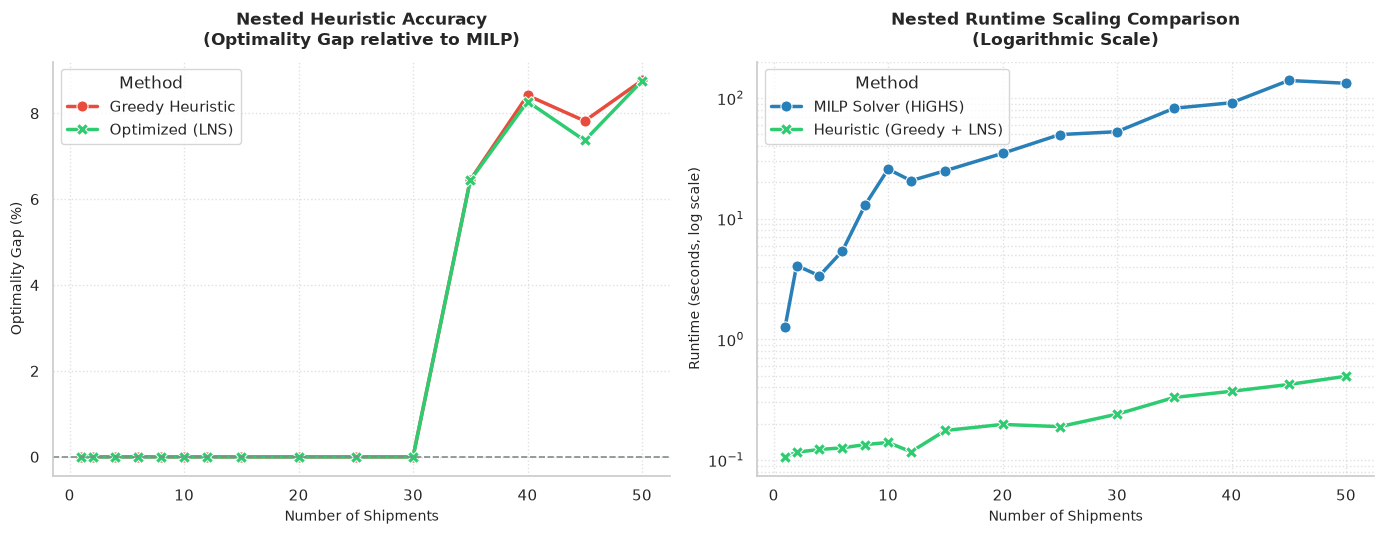

In [10]:
# Plotten der geschachtelten Ergebnisse
sizes = results_nested["size"]
if sizes:
    greedy_gaps = [
        (g - m) / m * 100 for g, m in zip(results_nested["greedy_obj"], results_nested["milp_obj"])
    ]
    opt_gaps = [
        (o - m) / m * 100 for o, m in zip(results_nested["opt_obj"], results_nested["milp_obj"])
    ]

    df_gap = pd.DataFrame(
        {
            "Shipment Size": sizes * 2,
            "Optimality Gap (%)": greedy_gaps + opt_gaps,
            "Method": ["Greedy Heuristic"] * len(sizes)
            + ["Optimized (LNS)"] * len(sizes),
        }
    )

    df_time = pd.DataFrame(
        {
            "Shipment Size": sizes * 2,
            "Runtime (seconds)": results_nested["milp_time"] + results_nested["opt_time"],
            "Method": ["MILP Solver (HiGHS)"] * len(sizes)
            + ["Heuristic (Greedy + LNS)"] * len(sizes),
        }
    )

    sns.set_theme(style="whitegrid", palette="muted")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Plot 1: Optimality Gap
    sns.lineplot(
        data=df_gap,
        x="Shipment Size",
        y="Optimality Gap (%)",
        hue="Method",
        style="Method",
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=8,
        ax=ax1,
        palette={"Greedy Heuristic": "#e74c3c", "Optimized (LNS)": "#2ecc71"},
    )
    ax1.axhline(0, color="#7f8c8d", linestyle="--", linewidth=1.2)
    ax1.set_title(
        "Nested Heuristic Accuracy\n(Optimality Gap relative to MILP)",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax1.set_xlabel("Number of Shipments", fontsize=10)
    ax1.set_ylabel("Optimality Gap (%)", fontsize=10)
    ax1.grid(True, linestyle=":", alpha=0.6)

    # Plot 2: Rechenzeiten
    sns.lineplot(
        data=df_time,
        x="Shipment Size",
        y="Runtime (seconds)",
        hue="Method",
        style="Method",
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=8,
        ax=ax2,
        palette={
            "MILP Solver (HiGHS)": "#2980b9",
            "Heuristic (Greedy + LNS)": "#2ecc71",
        },
    )
    ax2.set_yscale("log")
    ax2.set_title(
        "Nested Runtime Scaling Comparison\n(Logarithmic Scale)",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax2.set_xlabel("Number of Shipments", fontsize=10)
    ax2.set_ylabel("Runtime (seconds, log scale)", fontsize=10)
    ax2.grid(True, which="both", linestyle=":", alpha=0.6)

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No nested results to plot.")